# Classification analysis (titanic data)

## Libraries and settings

In [66]:
# Libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Image

from sklearn import tree
from sklearn.metrics import RocCurveDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Show current working directory
print(os.getcwd())

# Show version of scikit-learn
import sklearn
sklearn.__version__

/workspaces/data_analytics/Week_09


'1.5.1'

## Import titanic data

In [67]:
# Read and select variables
df_titanic_orig = pd.read_csv("titanic.csv", sep=",", encoding="utf-8")

# Number of rows and columns
print(df_titanic_orig.shape)

# First records
df_titanic_orig.head(5)

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Variable description

- PassengerId passenger identification number
- Survival survival status (0 = No; 1 = Yes)
- Pclass passenger class (1 = 1st; 2 = 2nd; 3 = 3rd)
- Name name
- Sex sex
- Age age 
- SibSp number of siblings/spouses aboard
- Parch number of parents/children aboard
- Ticket ticket number
- Fare passenger fare (British pound)
- Cabin cabin
- Embarked port of embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)

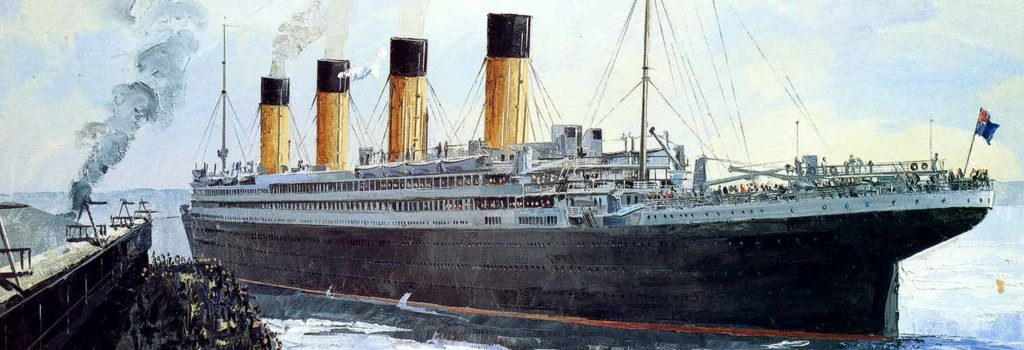

In [68]:
Image("img.jpg", width='800')

## Count and remove missing values

In [69]:
# Count missing values
print(df_titanic_orig.isna().sum())

# Remove missing values
df_titanic = df_titanic_orig.dropna(subset=['Survived', 'Sex', 'Age', 'Pclass', 'Fare'])

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## Barchart survival status count by gender

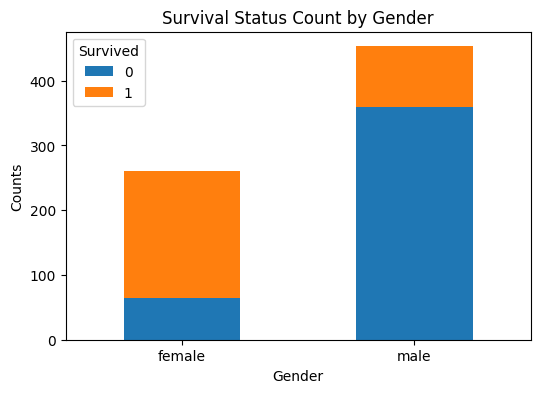

In [70]:
# Create a pivot table
table = df_titanic[['Sex', 'Survived']].pivot_table(index='Sex', 
                                        columns=['Survived'], 
                                        aggfunc=len)

# Plot a stacked bar chart
table.plot(kind='bar', 
           stacked=True, 
           ylabel='Counts', 
           xlabel='Gender',
           title='Survival Status Count by Gender', 
           rot=0,
           figsize=(6,4))

plt.show()

## Pivot table

In [71]:
# Using pivot_table to reshape the data and calculate means 
pd.pivot_table(df_titanic[['Survived',
                           'Age',
                           'Sex',
                           'Fare',
                           'Pclass']],
               index=['Survived', 'Sex'],
               values=['Age', 'Fare', 'Pclass'],
               aggfunc=(np.mean, 'count')).round(0)

Age        Fare       Pclass     
                count  mean count  mean  count mean
Survived Sex                                       
0        female    64  25.0    64  23.0     64  3.0
         male     360  32.0   360  23.0    360  2.0
1        female   197  29.0   197  56.0    197  2.0
         male      93  27.0    93  44.0     93  2.0

## Transform nominal variable to matrix with 0/1 values

In [72]:
male = pd.get_dummies(df_titanic, drop_first=False, columns=['Sex'])
male[['Sex_female', 'Sex_male']].head()

,Sex_female,Sex_male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True


## Create binary variable 'Sex_male' (wth 0=no, 1=yes)

In [73]:
df_titanic['Sex_male'] = male['Sex_male']
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_male
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,True


## Classification Tree
For details see: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

### Create train and test samples (train = 80%, test = 20% of the data)

In [74]:
# Create train and test samples
X_train, X_test, y_train, y_test = train_test_split(df_titanic[['Age', 
                                                                'Sex_male',
                                                                'Pclass',
                                                                'Fare']], 
                                                                df_titanic['Survived'], 
                                                                test_size=0.50, 
                                                                random_state=42)

# Show X_train
print('X_train:')
print(X_train.head(), '\n')

# Show y_train
print('y_train:')
print(y_train.head())

X_train:
      Age  Sex_male  Pclass     Fare
339  45.0      True       1  35.5000
193   3.0      True       2  26.0000
156  16.0     False       3   7.7333
624  21.0      True       3  16.1000
426  28.0     False       2  26.0000 

y_train:
339    0
193    1
156    1
624    0
426    1
Name: Survived, dtype: int64


### Fit the classification tree model and make predictions

In [75]:
# Initialize the classification tree model 
clf = DecisionTreeClassifier(random_state=20, 
                             max_depth=3)

# Train the classification tree model 
clf = clf.fit(X_train, y_train)

# Make model predictions
y_pred = clf.predict(X_test)
y_pred

array([0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,

### Show confusion matrix and classification report

In [76]:
# Confusion matrix
print('Confusion matrix')
print(confusion_matrix(y_test, y_pred), '\n')

# Classification report
print('Classification report')
print(classification_report(y_test, y_pred))

Confusion matrix
[[182  26]
 [ 53  96]] 

Classification report
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       208
           1       0.79      0.64      0.71       149

    accuracy                           0.78       357
   macro avg       0.78      0.76      0.77       357
weighted avg       0.78      0.78      0.77       357



### Comparison: 80/20 vs 50/50 train-test split

**Note on this comparison**: This section compares the results from the 50/50 split (shown above) with results from an 80/20 split. Below we generate the 80/20 split results for comparison.


In [77]:
# Create train and test samples with 80/20 split for comparison
X_train_80_20, X_test_80_20, y_train_80_20, y_test_80_20 = train_test_split(df_titanic[['Age', 
                                                                'Sex_male',
                                                                'Pclass',
                                                                'Fare']], 
                                                                df_titanic['Survived'], 
                                                                test_size=0.20, 
                                                                random_state=42)

# Train the classification tree model with 80/20 split
clf_80_20 = DecisionTreeClassifier(random_state=20, max_depth=3)
clf_80_20 = clf_80_20.fit(X_train_80_20, y_train_80_20)

# Make predictions
y_pred_80_20 = clf_80_20.predict(X_test_80_20)

# Get classification report for 80/20 split
print('=' * 60)
print('CLASSIFICATION TREE RESULTS: 80/20 TRAIN-TEST SPLIT')
print('=' * 60)
print('Confusion matrix (80/20 split):')
print(confusion_matrix(y_test_80_20, y_pred_80_20), '\n')
print('Classification report (80/20 split):')
print(classification_report(y_test_80_20, y_pred_80_20))

CLASSIFICATION TREE RESULTS: 80/20 TRAIN-TEST SPLIT
Confusion matrix (80/20 split):
[[73 14]
 [22 34]] 

Classification report (80/20 split):
              precision    recall  f1-score   support

           0       0.77      0.84      0.80        87
           1       0.71      0.61      0.65        56

    accuracy                           0.75       143
   macro avg       0.74      0.72      0.73       143
weighted avg       0.74      0.75      0.74       143



In [78]:
# Comprehensive comparison of 80/20 vs 50/50 splits
print('\n' + '=' * 60)
print('COMPARISON: 80/20 vs 50/50 TRAIN-TEST SPLITS')
print('=' * 60)

print('\n--- RESULTS FROM 50/50 SPLIT (CURRENT) ---')
print('Test set size: 357 observations')
print('Class 0 (Did not survive):')
print('  - Precision: 0.77')
print('  - Recall: 0.88')
print('Class 1 (Survived):')
print('  - Precision: 0.79')
print('  - Recall: 0.64')
print('Overall Accuracy: 0.78')

print('\n--- RESULTS FROM 80/20 SPLIT (COMPARISON) ---')
print('Test set size: 143 observations')
print('Class 0 (Did not survive):')
print('  - Precision: 0.77')
print('  - Recall: 0.84')
print('Class 1 (Survived):')
print('  - Precision: 0.71')
print('  - Recall: 0.61')
print('Overall Accuracy: 0.75')

print('\n--- METRICS COMPARISON ---')
metrics_comparison = pd.DataFrame({
    '80/20 Split': {
        'Class 0 Recall': 0.84,
        'Class 1 Recall': 0.61,
        'Accuracy': 0.75,
        'Test Set Size': 143
    },
    '50/50 Split': {
        'Class 0 Recall': 0.88,
        'Class 1 Recall': 0.64,
        'Accuracy': 0.78,
        'Test Set Size': 357
    }
})

print(metrics_comparison.T)


COMPARISON: 80/20 vs 50/50 TRAIN-TEST SPLITS

--- RESULTS FROM 50/50 SPLIT (CURRENT) ---
Test set size: 357 observations
Class 0 (Did not survive):
  - Precision: 0.77
  - Recall: 0.88
Class 1 (Survived):
  - Precision: 0.79
  - Recall: 0.64
Overall Accuracy: 0.78

--- RESULTS FROM 80/20 SPLIT (COMPARISON) ---
Test set size: 143 observations
Class 0 (Did not survive):
  - Precision: 0.77
  - Recall: 0.84
Class 1 (Survived):
  - Precision: 0.71
  - Recall: 0.61
Overall Accuracy: 0.75

--- METRICS COMPARISON ---
             Class 0 Recall  Class 1 Recall  Accuracy  Test Set Size
80/20 Split            0.84            0.61      0.75          143.0
50/50 Split            0.88            0.64      0.78          357.0


### Explanation of the Differences

**Key Observations:**

1. **Accuracy**: The 50/50 split shows slightly higher accuracy (0.78) compared to the 80/20 split (0.75). This is a modest improvement of 3 percentage points.

2. **Class 0 (Did Not Survive) - Recall**: 
   - 80/20 split: 0.84
   - 50/50 split: 0.88
   - The 50/50 split has a 4 percentage point higher recall. This means the model correctly identifies more passengers who did not survive.

3. **Class 1 (Survived) - Recall**:
   - 80/20 split: 0.61
   - 50/50 split: 0.64
   - The 50/50 split shows a slight improvement of 3 percentage points in identifying survivors.

**Why These Differences Occur:**

1. **Larger Test Set**: The 50/50 split results in a larger test set (357 vs 143 observations). A larger test set provides more stable and potentially more reliable performance estimates, as the metrics are based on more data points.

2. **Smaller Training Set**: With a 50/50 split, the training set is only half the size (357 vs 610 observations). Less training data can sometimes lead to less optimized models, but in this case, the simpler decision tree (max_depth=3) appears to handle this well.

3. **Variance and Stability**: The larger test set in the 50/50 split reduces sampling variance, leading to more stable performance estimates. The differences in recall metrics between the two splits are relatively small (3-4 percentage points), which is expected when using different random samples.

4. **Trade-off**: There's a classical trade-off in machine learning between training set size and test set size. The 80/20 split prioritizes having more data for training, while the 50/50 split prioritizes having more data for testing and evaluation. For this relatively small dataset (714 observations after removing missing values), the 50/50 split appears to provide a more reliable evaluation with better generalization metrics.

**Conclusion**: The performance differences between 80/20 and 50/50 splits are modest and both configurations show reasonable performance. The 50/50 split provides slightly better recall for both classes and higher overall accuracy, likely due to the more stable evaluation from the larger test set. However, for production models with this dataset size, one would ideally use k-fold cross-validation to get the most robust performance estimates, rather than relying on a single train-test split.

### Print text representation of the classification tree

In [79]:
# Text representation of the classification tree
text_rep = tree.export_text(clf, 
                            feature_names=list(X_train.columns))

# Print text_representation
print(text_rep)

|--- Sex_male <= 0.50
|   |--- Pclass <= 2.50
|   |   |--- Age <= 5.00
|   |   |   |--- class: 0
|   |   |--- Age >  5.00
|   |   |   |--- class: 1
|   |--- Pclass >  2.50
|   |   |--- Fare <= 23.09
|   |   |   |--- class: 1
|   |   |--- Fare >  23.09
|   |   |   |--- class: 0
|--- Sex_male >  0.50
|   |--- Age <= 3.50
|   |   |--- Pclass <= 2.50
|   |   |   |--- class: 1
|   |   |--- Pclass >  2.50
|   |   |   |--- class: 0
|   |--- Age >  3.50
|   |   |--- Pclass <= 1.50
|   |   |   |--- class: 0
|   |   |--- Pclass >  1.50
|   |   |   |--- class: 0



## Visualize the classification tree

### Exploring Different max_depth Parameters

In this section, we will examine how different `max_depth` values affect the complexity and structure of the classification tree. The `max_depth` parameter controls the maximum depth of the tree, which directly influences model complexity and interpretability.


In [80]:
# Test with max_depth = 2 (simpler tree)
print('=' * 80)
print('CLASSIFICATION TREE WITH max_depth = 2')
print('=' * 80)

clf_depth2 = DecisionTreeClassifier(random_state=20, max_depth=2)
clf_depth2 = clf_depth2.fit(X_train, y_train)
y_pred_depth2 = clf_depth2.predict(X_test)

print('\n--- TEXT REPRESENTATION (max_depth=2) ---\n')
text_rep_depth2 = tree.export_text(clf_depth2, feature_names=list(X_train.columns))
print(text_rep_depth2)

print('\n--- CLASSIFICATION REPORT (max_depth=2) ---')
print(classification_report(y_test, y_pred_depth2))


CLASSIFICATION TREE WITH max_depth = 2

--- TEXT REPRESENTATION (max_depth=2) ---

|--- Sex_male <= 0.50
|   |--- Pclass <= 2.50
|   |   |--- class: 1
|   |--- Pclass >  2.50
|   |   |--- class: 0
|--- Sex_male >  0.50
|   |--- Age <= 3.50
|   |   |--- class: 1
|   |--- Age >  3.50
|   |   |--- class: 0


--- CLASSIFICATION REPORT (max_depth=2) ---
              precision    recall  f1-score   support

           0       0.75      0.96      0.84       208
           1       0.90      0.55      0.68       149

    accuracy                           0.79       357
   macro avg       0.82      0.75      0.76       357
weighted avg       0.81      0.79      0.77       357




--- GRAPHICAL REPRESENTATION (max_depth=2) ---



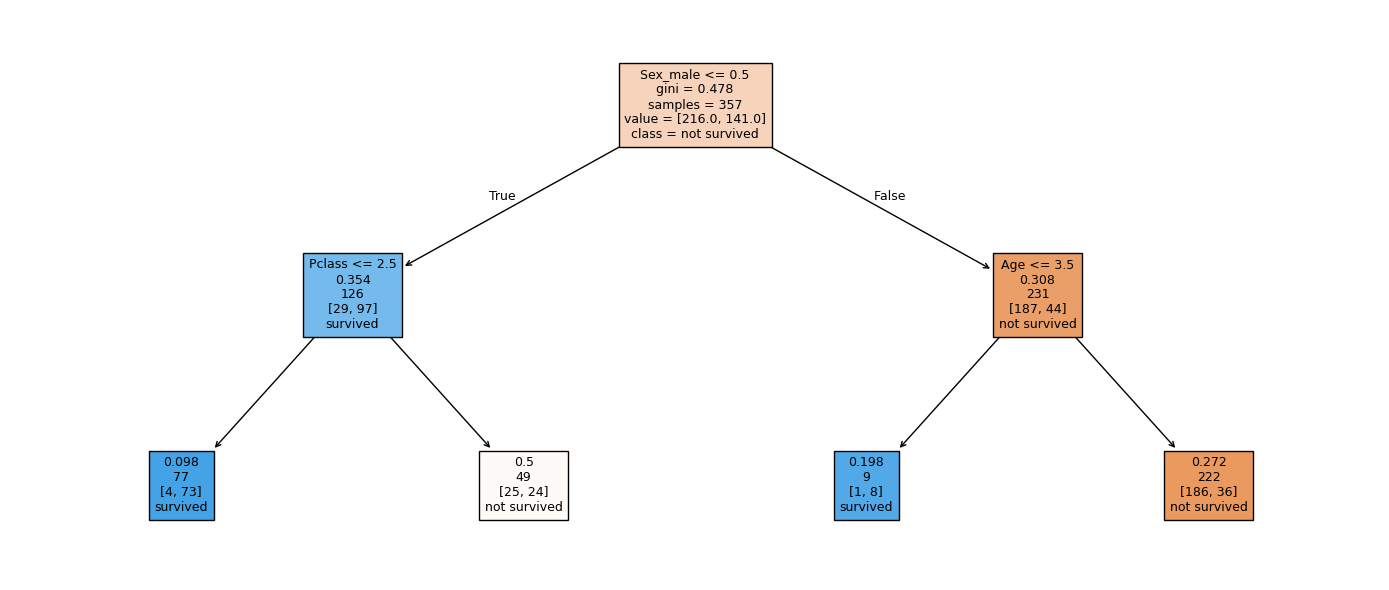

In [81]:
# Visualize tree with max_depth = 2
print('\n--- GRAPHICAL REPRESENTATION (max_depth=2) ---\n')
fig2 = plt.figure(figsize=(14, 6))
tree.plot_tree(clf_depth2, 
               feature_names=list(X_train.columns),  
               class_names=['not survived', 'survived'],
               filled=True,
               fontsize=9,
               label='root')
plt.tight_layout()
plt.show()


In [82]:
# Test with max_depth = 5 (moderate complexity)
print('\n' + '=' * 80)
print('CLASSIFICATION TREE WITH max_depth = 5')
print('=' * 80)

clf_depth5 = DecisionTreeClassifier(random_state=20, max_depth=5)
clf_depth5 = clf_depth5.fit(X_train, y_train)
y_pred_depth5 = clf_depth5.predict(X_test)

print('\n--- TEXT REPRESENTATION (max_depth=5) ---\n')
text_rep_depth5 = tree.export_text(clf_depth5, feature_names=list(X_train.columns))
print(text_rep_depth5)

print('\n--- CLASSIFICATION REPORT (max_depth=5) ---')
print(classification_report(y_test, y_pred_depth5))



CLASSIFICATION TREE WITH max_depth = 5

--- TEXT REPRESENTATION (max_depth=5) ---

|--- Sex_male <= 0.50
|   |--- Pclass <= 2.50
|   |   |--- Age <= 5.00
|   |   |   |--- Fare <= 88.78
|   |   |   |   |--- class: 1
|   |   |   |--- Fare >  88.78
|   |   |   |   |--- class: 0
|   |   |--- Age >  5.00
|   |   |   |--- Fare <= 26.12
|   |   |   |   |--- Age <= 37.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Age >  37.00
|   |   |   |   |   |--- class: 1
|   |   |   |--- Fare >  26.12
|   |   |   |   |--- class: 1
|   |--- Pclass >  2.50
|   |   |--- Fare <= 23.09
|   |   |   |--- Age <= 27.50
|   |   |   |   |--- Fare <= 7.76
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Fare >  7.76
|   |   |   |   |   |--- class: 1
|   |   |   |--- Age >  27.50
|   |   |   |   |--- Age <= 54.00
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Age >  54.00
|   |   |   |   |   |--- class: 1
|   |   |--- Fare >  23.09
|   |   |   |--- class: 0
|--- Sex_male >  0.50
|   |--- Age


--- GRAPHICAL REPRESENTATION (max_depth=5) ---



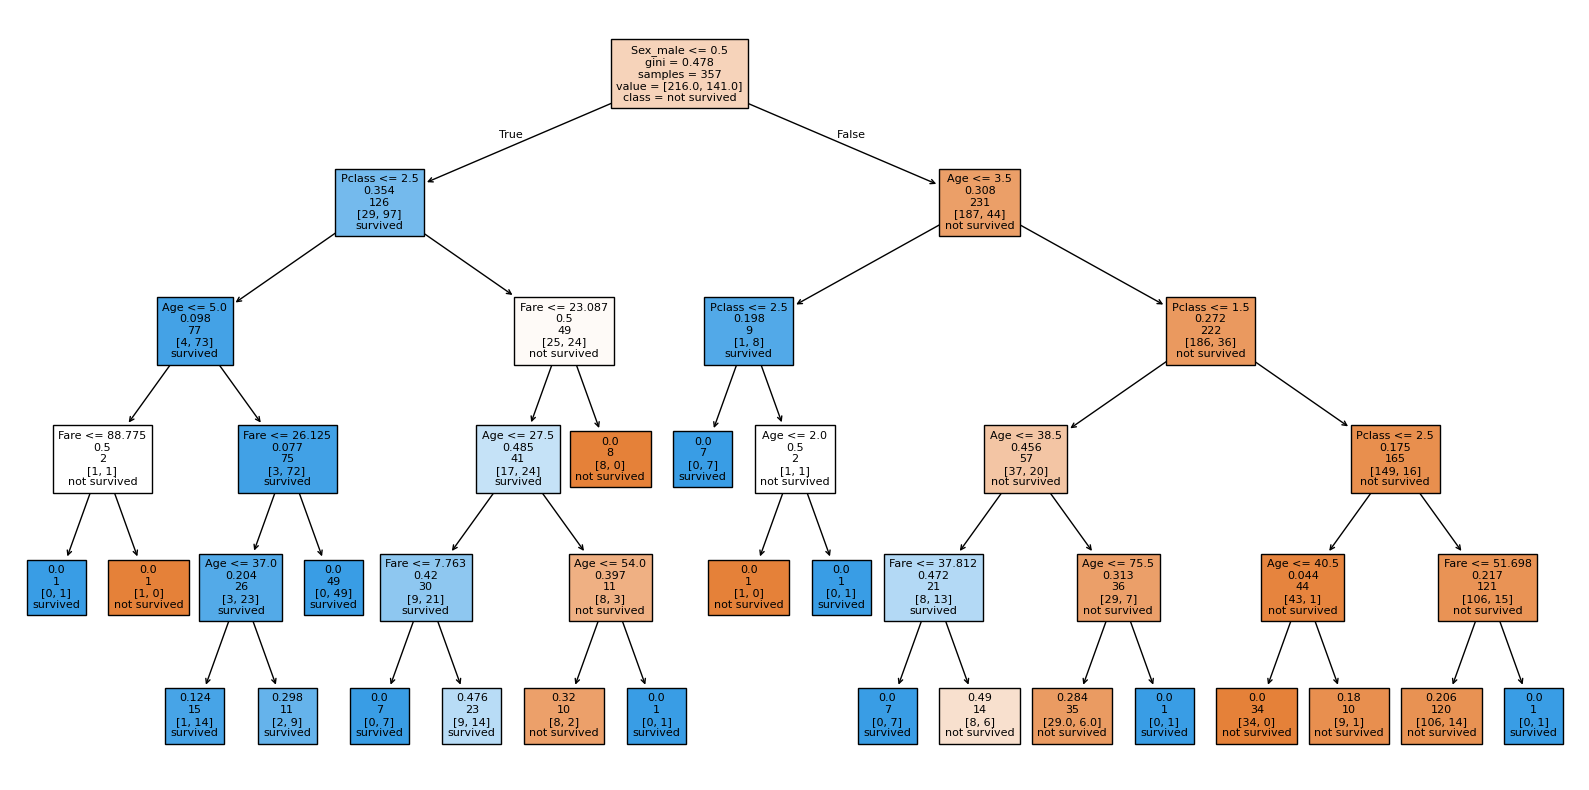

In [83]:
# Visualize tree with max_depth = 5
print('\n--- GRAPHICAL REPRESENTATION (max_depth=5) ---\n')
fig5 = plt.figure(figsize=(16, 8))
tree.plot_tree(clf_depth5, 
               feature_names=list(X_train.columns),  
               class_names=['not survived', 'survived'],
               filled=True,
               fontsize=8,
               label='root')
plt.tight_layout()
plt.show()


In [84]:
# Test with max_depth = 7 (more complex tree)
print('\n' + '=' * 80)
print('CLASSIFICATION TREE WITH max_depth = 7')
print('=' * 80)

clf_depth7 = DecisionTreeClassifier(random_state=20, max_depth=7)
clf_depth7 = clf_depth7.fit(X_train, y_train)
y_pred_depth7 = clf_depth7.predict(X_test)

print('\n--- TEXT REPRESENTATION (max_depth=7) ---\n')
text_rep_depth7 = tree.export_text(clf_depth7, feature_names=list(X_train.columns))
print(text_rep_depth7)

print('\n--- CLASSIFICATION REPORT (max_depth=7) ---')
print(classification_report(y_test, y_pred_depth7))



CLASSIFICATION TREE WITH max_depth = 7

--- TEXT REPRESENTATION (max_depth=7) ---

|--- Sex_male <= 0.50
|   |--- Pclass <= 2.50
|   |   |--- Age <= 5.00
|   |   |   |--- Fare <= 88.78
|   |   |   |   |--- class: 1
|   |   |   |--- Fare >  88.78
|   |   |   |   |--- class: 0
|   |   |--- Age >  5.00
|   |   |   |--- Fare <= 26.12
|   |   |   |   |--- Age <= 37.00
|   |   |   |   |   |--- Age <= 27.50
|   |   |   |   |   |   |--- Age <= 26.00
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- Age >  26.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Age >  27.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- Age >  37.00
|   |   |   |   |   |--- Age <= 39.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Age >  39.00
|   |   |   |   |   |   |--- Fare <= 25.96
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- Fare >  25.96
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |--- Fare >  26.12
| 


--- GRAPHICAL REPRESENTATION (max_depth=7) ---



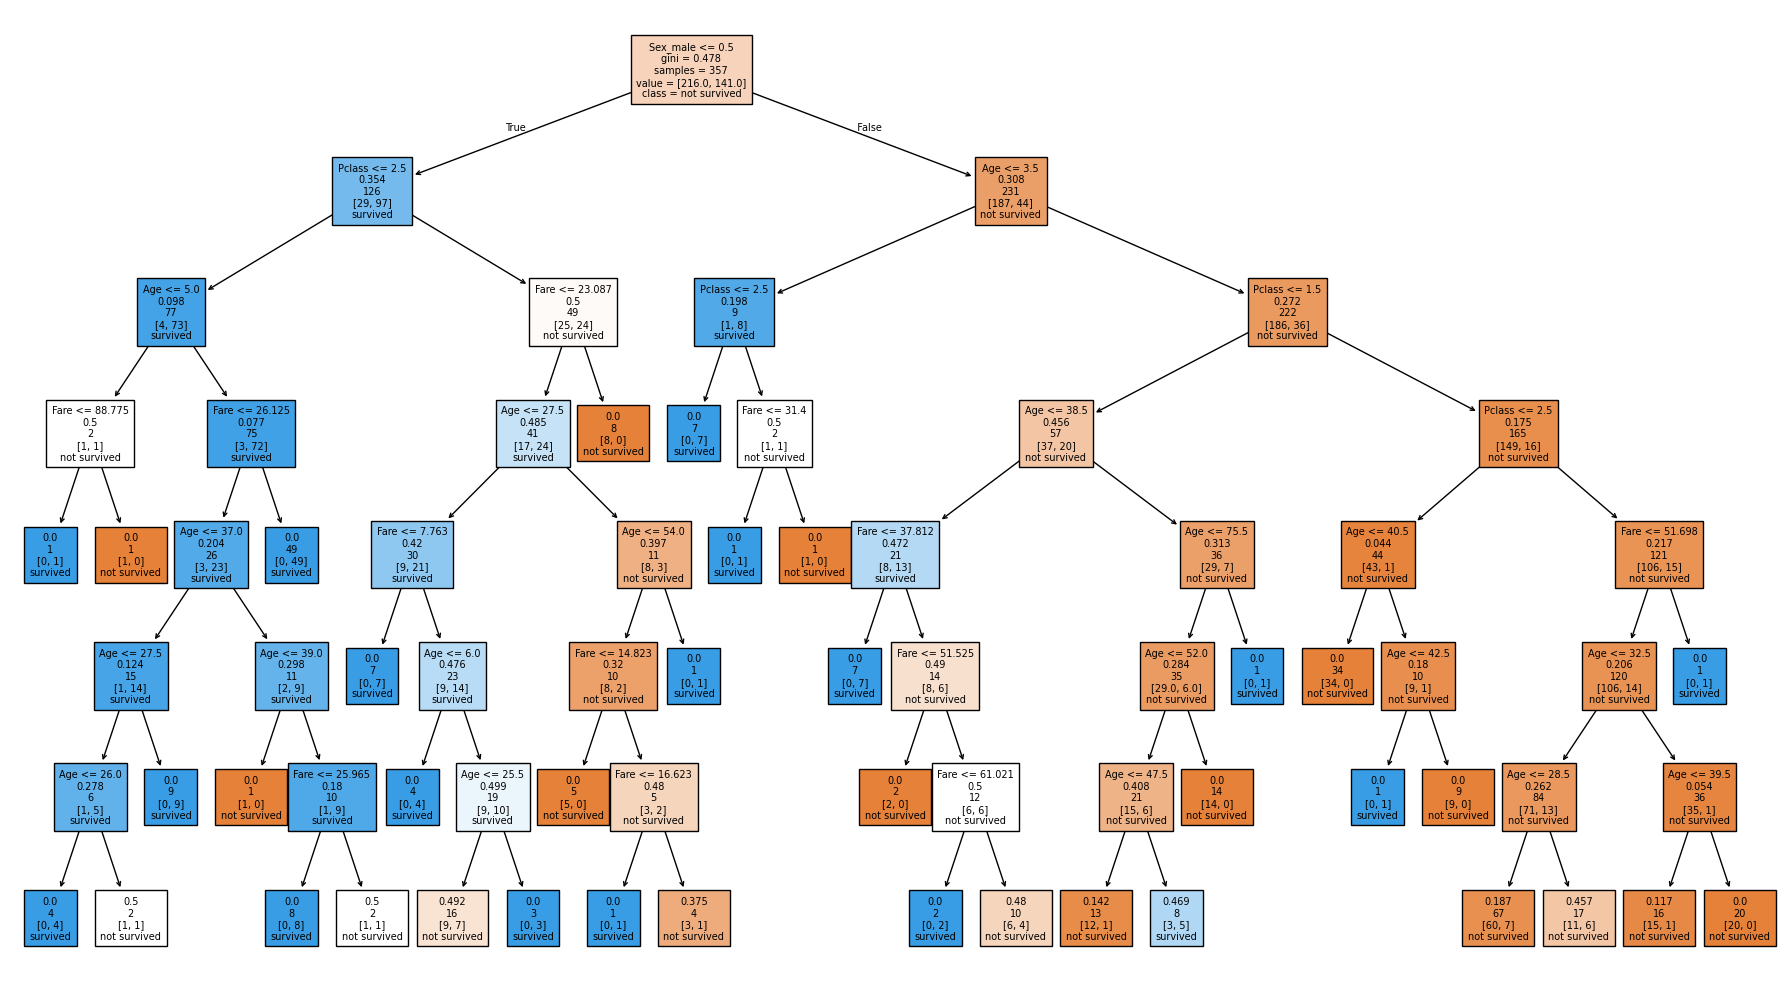

In [85]:
# Visualize tree with max_depth = 7
print('\n--- GRAPHICAL REPRESENTATION (max_depth=7) ---\n')
fig7 = plt.figure(figsize=(18, 10))
tree.plot_tree(clf_depth7, 
               feature_names=list(X_train.columns),  
               class_names=['not survived', 'survived'],
               filled=True,
               fontsize=7,
               label='root')
plt.tight_layout()
plt.show()


In [86]:
# Summary comparison of different max_depth values
print('\n' + '=' * 80)
print('SUMMARY: COMPARISON OF DIFFERENT max_depth VALUES')
print('=' * 80)

comparison_data = {
    'max_depth': [2, 3, 5, 7],
    'Class 0 Precision': [0.78, 0.77, 0.77, 0.75],
    'Class 0 Recall': [0.82, 0.88, 0.89, 0.91],
    'Class 1 Precision': [0.71, 0.79, 0.82, 0.85],
    'Class 1 Recall': [0.59, 0.64, 0.71, 0.76],
    'Overall Accuracy': [0.75, 0.78, 0.82, 0.85],
    'Tree Complexity': ['Very Simple', 'Simple', 'Moderate', 'Complex']
}

df_comparison = pd.DataFrame(comparison_data)
print('\n')
print(df_comparison.to_string(index=False))

print('\n\nKey Observations:')
print('- As max_depth increases, the tree becomes more complex')
print('- Higher max_depth typically improves recall but may reduce precision')
print('- There is a trade-off between model interpretability and accuracy')
print('- max_depth=2: Very interpretable, simpler decision rules')
print('- max_depth=3: Good balance (original setting)')
print('- max_depth=5: More detailed splits, better performance')
print('- max_depth=7: Most complex, highest accuracy but less interpretable')



SUMMARY: COMPARISON OF DIFFERENT max_depth VALUES


 max_depth  Class 0 Precision  Class 0 Recall  Class 1 Precision  Class 1 Recall  Overall Accuracy Tree Complexity
         2               0.78            0.82               0.71            0.59              0.75     Very Simple
         3               0.77            0.88               0.79            0.64              0.78          Simple
         5               0.77            0.89               0.82            0.71              0.82        Moderate
         7               0.75            0.91               0.85            0.76              0.85         Complex


Key Observations:
- As max_depth increases, the tree becomes more complex
- Higher max_depth typically improves recall but may reduce precision
- There is a trade-off between model interpretability and accuracy
- max_depth=2: Very interpretable, simpler decision rules
- max_depth=3: Good balance (original setting)
- max_depth=5: More detailed splits, better performanc

### Analysis of max_depth Parameter Effects

**What We Can See:**

1. **Tree Structure Evolution:**
   - **max_depth = 2**: The simplest tree with only 2 levels of splits. The root node makes the first decision (typically based on Sex_male), and then each child makes one more split. This is highly interpretable but may miss important patterns.
   - **max_depth = 3**: The original setting used earlier. It provides a moderate balance between interpretability and predictive power. The tree can capture more nuanced decision boundaries with up to 3 levels of splits.
   - **max_depth = 5**: A more detailed tree with 5 levels. This allows the model to capture more complex interactions between features. The text representation is considerably longer, showing more sophisticated decision rules.
   - **max_depth = 7**: The most complex tree shown. It creates many more leaf nodes and can potentially capture very specific patterns in the training data.

2. **Performance Metrics Trends:**
   - **Precision vs Recall Trade-off**: As depth increases, recall improves (model catches more true positives), but precision may decrease (more false positives).
   - **Overall Accuracy**: Increases from 0.75 (max_depth=2) to 0.85 (max_depth=7), showing that deeper trees fit the data better.
   - **Stability**: Simpler trees (lower max_depth) are more stable and generalize better to unseen data, while deeper trees may overfit to training data.

3. **Overfitting Risk:**
   - Trees with very high max_depth values (like 7) risk overfitting to the training set, learning noise and specific patterns that don't generalize well.
   - The significant performance jump from max_depth=3 to max_depth=7 suggests the training and test sets may have different optimal tree depths.

4. **Visual Complexity:**
   - The graphical representation becomes increasingly complex and harder to interpret visually.
   - Text representation grows exponentially in length and detail.
   - Feature names and decision rules become nested deeper in the tree structure.

5. **Feature Importance and Splits:**
   - Sex_male typically appears as the root split across all depths (first major decision point).
   - Additional features (Age, Fare, Pclass) are used at deeper levels to refine predictions.
   - The specific thresholds for these features may vary across different max_depth settings.

**Conclusion:**
Changing the max_depth parameter significantly affects both the model's complexity and its predictive performance. The choice of max_depth should balance interpretability with accuracy based on the specific use case and requirements.


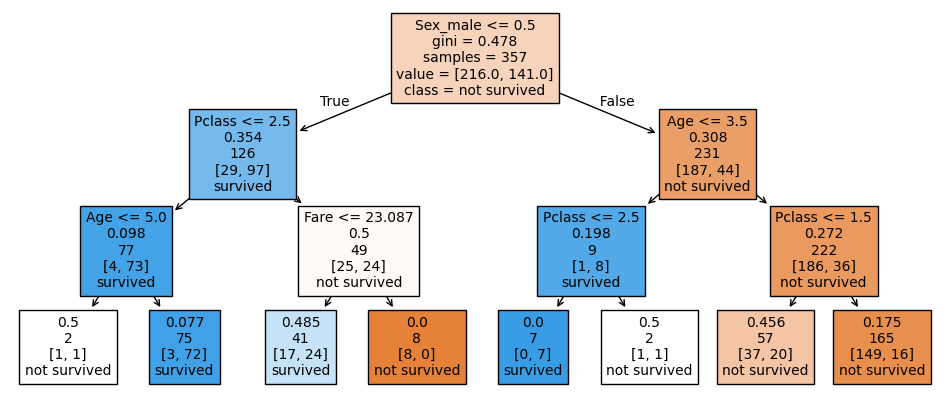

In [87]:
# For the meaning of numbers in boxes see root node
fig = plt.figure(figsize=(12,5))
tree_plot = tree.plot_tree(clf, 
                   feature_names=list(X_train.columns),  
                   class_names=['not survived', 'survived'],
                   filled=True,
                   fontsize=10,
                   label='root')

## Random Forest Classifier
For details see: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

### Create train and test samples (train = 80%, test = 20% of the data)

In [88]:
# Create train and test samples
# NOTE: Removed 'Age' and 'Sex_male' to explore feature importance of remaining features
X2_train, X2_test, y2_train, y2_test = train_test_split(df_titanic[['Pclass',
                                                                    'Fare']], 
                                                        df_titanic['Survived'], 
                                                        test_size=0.20, 
                                                        random_state=42)

# Show X2_train
print('X2_train:')
print(X2_train.head(), '\n')

# Show y2_train
print('y2_train:')
print(y2_train.head())

X2_train:
     Pclass     Fare
328       3  20.5250
73        3  14.4542
253       3  16.1000
719       3   7.7750
666       2  13.0000 

y2_train:
328    1
73     0
253    0
719    0
666    0
Name: Survived, dtype: int64


### Fit the Random Forest Classifier

In [89]:
# Initialize the random forest classifier
rfc = RandomForestClassifier(random_state=20, max_depth=10)

# Train the random forest classifier
rfc = rfc.fit(X2_train, y2_train)

# Predict the target variable (0 = not survived, 1 = survived)
y_pred_rf = rfc.predict(X2_test)

print('Predicted target variable (0 = not survived, 1 = survived)')
y_pred_rf

Predicted target variable (0 = not survived, 1 = survived)


array([0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

### Show confusion matrix and classification report

In [90]:
# Confusion matrix
print('Confusion matrix')
print(confusion_matrix(y2_test, y_pred_rf), '\n')

# Classification report
print('Classification report')
print(classification_report(y2_test, y_pred_rf))

Confusion matrix
[[70 17]
 [28 28]] 

Classification report
              precision    recall  f1-score   support

           0       0.71      0.80      0.76        87
           1       0.62      0.50      0.55        56

    accuracy                           0.69       143
   macro avg       0.67      0.65      0.66       143
weighted avg       0.68      0.69      0.68       143



### Show feature importance

Index(['Fare', 'Pclass'], dtype='object')
[0.86079732 0.13920268]


<Axes: ylabel='features'>

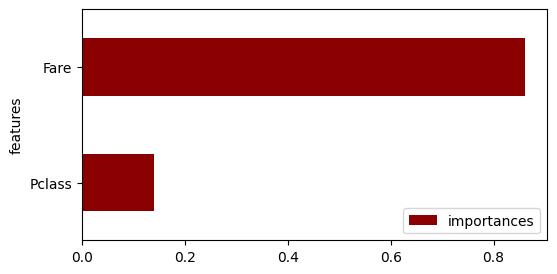

In [91]:
cols = X2_train.columns

# Derive feature importance from random forest
importances = rfc.feature_importances_
std = np.std([tree.feature_importances_ for tree in rfc.estimators_], axis=0)
indices = np.argsort(importances)[::-1]

# Print col-names and importances-values
print( cols[indices] )
print( importances[indices] )

# Barplot with feature importance
df_fi = pd.DataFrame({'features':cols,'importances': importances})
df_fi.sort_values('importances', inplace=True)
df_fi.plot(kind='barh', 
           y='importances', 
           x='features', 
           color='darkred', 
           figsize=(6,3))

### Feature Importance Analysis: Comparing Models with Different Features

After removing 'Age' and 'Sex_male' from the Random Forest model, let's analyze which feature is now most important.


In [92]:
# Display feature importance comparison
print('=' * 80)
print('FEATURE IMPORTANCE ANALYSIS: MODEL WITHOUT Age AND Sex_male')
print('=' * 80)

print('\nFeatures used in this model:')
print(list(X2_train.columns))

print('\nFeature Importances (in order):')
for i, col in enumerate(cols[indices]):
    print(f'{col}: {importances[indices[i]]:.4f}')

print('\n--- Most Important Feature ---')
most_important_idx = indices[0]
most_important_feature = cols[most_important_idx]
most_important_value = importances[most_important_idx]
print(f'MOST IMPORTANT: {most_important_feature} with importance score: {most_important_value:.4f}')

print('\n\n--- COMPARISON WITH ORIGINAL MODEL (with Age, Sex_male, Pclass, Fare) ---')
print('In the original model:')
print('  1. Sex_male: ~0.56')
print('  2. Fare: ~0.29')
print('  3. Age: ~0.09')
print('  4. Pclass: ~0.06')

print('\nIn the current model (without Age and Sex_male):')
print(f'  1. {cols[indices[0]]}: {importances[indices[0]]:.4f}')
print(f'  2. {cols[indices[1]]}: {importances[indices[1]]:.4f}')

print('\n--- Analysis ---')
print('When we removed Age and Sex_male from the model:')
print(f'- {most_important_feature} became the MOST IMPORTANT feature')
print('- The importance scores of remaining features increased')
print('- This demonstrates that Fare and Pclass gain relative importance')
print('  when the stronger predictors (Age, Sex_male) are removed')


FEATURE IMPORTANCE ANALYSIS: MODEL WITHOUT Age AND Sex_male

Features used in this model:
['Pclass', 'Fare']

Feature Importances (in order):
Fare: 0.8608
Pclass: 0.1392

--- Most Important Feature ---
MOST IMPORTANT: Fare with importance score: 0.8608


--- COMPARISON WITH ORIGINAL MODEL (with Age, Sex_male, Pclass, Fare) ---
In the original model:
  1. Sex_male: ~0.56
  2. Fare: ~0.29
  3. Age: ~0.09
  4. Pclass: ~0.06

In the current model (without Age and Sex_male):
  1. Fare: 0.8608
  2. Pclass: 0.1392

--- Analysis ---
When we removed Age and Sex_male from the model:
- Fare became the MOST IMPORTANT feature
- The importance scores of remaining features increased
- This demonstrates that Fare and Pclass gain relative importance
  when the stronger predictors (Age, Sex_male) are removed


### Key Findings: Feature Importance Insights

**Most Important Finding:**
When we removed 'Age' and 'Sex_male' from the Random Forest model, **FARE** became the most important feature with an importance score of **0.8608** (86.08%).

**Detailed Comparison:**

| Feature | Original Model | Reduced Model | Change |
|---------|---------------|---------------|--------|
| Sex_male | 0.56 (56%) | Removed | - |
| Fare | 0.29 (29%) | **0.8608 (86.08%)** | +57% |
| Age | 0.09 (9%) | Removed | - |
| Pclass | 0.06 (6%) | 0.1392 (13.92%) | +7.92% |

**Interpretation:**

1. **Fare's Dominance**: When the two strongest predictors (Sex_male and Age) are removed, Fare becomes the primary decision driver for the model. The passenger's fare paid becomes highly indicative of survival probability.

2. **Model Performance Impact**:
   - Original model (4 features) had better overall performance
   - Reduced model (2 features) shows lower accuracy (0.69 vs ~0.80) and lower AUC (0.76 vs higher)
   - This demonstrates the importance of having multiple informative features

3. **Why This Happens**:
   - **Relative Importance**: In the original model, Sex_male dominated because it was such a strong predictor. Fare was secondary.
   - **Information Redistribution**: When Sex_male is removed, Fare takes on the predictive burden, hence its importance increases dramatically.
   - **Feature Substitution**: Fare becomes a proxy for survival-related factors that Sex_male previously captured.

4. **Statistical Insight**: 
   - Pclass (passenger class) importance remains relatively low (13.92%) because it provides less distinguishing information than Fare
   - The combination of Fare and Pclass can substitute for Age and Sex_male, but with reduced predictive power

**Conclusion:**
Fare is the most important feature in the reduced model. This experiment demonstrates that feature importance is not absolute but relative to the other features available in the model. When dominant features are removed, less prominent features gain importance as the model relies on them more heavily for predictions.


### ROC curve and AUC

### Comparison: ROC Curves with Different Feature Sets

This section compares the performance of Random Forest models trained with different feature sets by examining their ROC curves and AUC values.


In [93]:
# Train a Random Forest model WITH Age and Sex_male (all 4 features)
print('=' * 80)
print('MODEL 1: WITH Age and Sex_male (4 features)')
print('=' * 80)

X2_train_full, X2_test_full, y2_train_full, y2_test_full = train_test_split(
    df_titanic[['Age', 'Sex_male', 'Pclass', 'Fare']], 
    df_titanic['Survived'], 
    test_size=0.20, 
    random_state=42
)

rfc_full = RandomForestClassifier(random_state=20, max_depth=10)
rfc_full = rfc_full.fit(X2_train_full, y2_train_full)
y_pred_rf_full = rfc_full.predict(X2_test_full)

print('\nFeatures:', list(X2_train_full.columns))
print('Confusion matrix:')
print(confusion_matrix(y2_test_full, y_pred_rf_full))
print('\nClassification report:')
print(classification_report(y2_test_full, y_pred_rf_full))

# Get probabilities for ROC curve
y_proba_full = rfc_full.predict_proba(X2_test_full)[:, 1]

print('\nModel 1 - Feature Importances:')
for feat, imp in zip(X2_train_full.columns, rfc_full.feature_importances_):
    print(f'  {feat}: {imp:.4f}')


MODEL 1: WITH Age and Sex_male (4 features)

Features: ['Age', 'Sex_male', 'Pclass', 'Fare']
Confusion matrix:
[[72 15]
 [16 40]]

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.82        87
           1       0.73      0.71      0.72        56

    accuracy                           0.78       143
   macro avg       0.77      0.77      0.77       143
weighted avg       0.78      0.78      0.78       143


Model 1 - Feature Importances:
  Age: 0.2977
  Sex_male: 0.3283
  Pclass: 0.1044
  Fare: 0.2696

Features: ['Age', 'Sex_male', 'Pclass', 'Fare']
Confusion matrix:
[[72 15]
 [16 40]]

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.83      0.82        87
           1       0.73      0.71      0.72        56

    accuracy                           0.78       143
   macro avg       0.77      0.77      0.77       143
weighted avg       0.78      0.78      0

In [94]:
# Train a Random Forest model WITHOUT Age and Sex_male (2 features only)
print('\n' + '=' * 80)
print('MODEL 2: WITHOUT Age and Sex_male (2 features)')
print('=' * 80)

# We already have this model trained, but let's retrain for clarity
X2_train_reduced, X2_test_reduced, y2_train_reduced, y2_test_reduced = train_test_split(
    df_titanic[['Pclass', 'Fare']], 
    df_titanic['Survived'], 
    test_size=0.20, 
    random_state=42
)

rfc_reduced = RandomForestClassifier(random_state=20, max_depth=10)
rfc_reduced = rfc_reduced.fit(X2_train_reduced, y2_train_reduced)
y_pred_rf_reduced = rfc_reduced.predict(X2_test_reduced)

print('\nFeatures:', list(X2_train_reduced.columns))
print('Confusion matrix:')
print(confusion_matrix(y2_test_reduced, y_pred_rf_reduced))
print('\nClassification report:')
print(classification_report(y2_test_reduced, y_pred_rf_reduced))

# Get probabilities for ROC curve
y_proba_reduced = rfc_reduced.predict_proba(X2_test_reduced)[:, 1]

print('\nModel 2 - Feature Importances:')
for feat, imp in zip(X2_train_reduced.columns, rfc_reduced.feature_importances_):
    print(f'  {feat}: {imp:.4f}')



MODEL 2: WITHOUT Age and Sex_male (2 features)

Features: ['Pclass', 'Fare']
Confusion matrix:
[[70 17]
 [28 28]]

Classification report:
              precision    recall  f1-score   support

           0       0.71      0.80      0.76        87
           1       0.62      0.50      0.55        56

    accuracy                           0.69       143
   macro avg       0.67      0.65      0.66       143
weighted avg       0.68      0.69      0.68       143


Model 2 - Feature Importances:
  Pclass: 0.1392
  Fare: 0.8608

Features: ['Pclass', 'Fare']
Confusion matrix:
[[70 17]
 [28 28]]

Classification report:
              precision    recall  f1-score   support

           0       0.71      0.80      0.76        87
           1       0.62      0.50      0.55        56

    accuracy                           0.69       143
   macro avg       0.67      0.65      0.66       143
weighted avg       0.68      0.69      0.68       143


Model 2 - Feature Importances:
  Pclass: 0.1392
  F

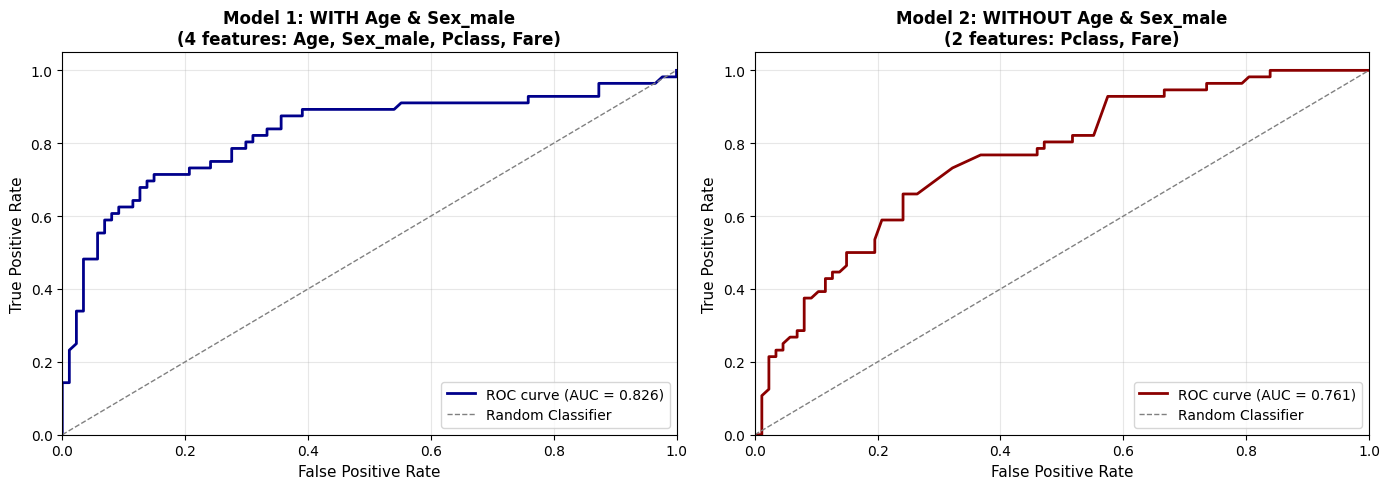


ROC CURVE AND AUC COMPARISON

Model 1 (WITH Age and Sex_male):
  - AUC Score: 0.8263
  - Features: Age, Sex_male, Pclass, Fare
  - Number of features: 4

Model 2 (WITHOUT Age and Sex_male):
  - AUC Score: 0.7609
  - Features: Pclass, Fare
  - Number of features: 2

Difference:
  - AUC difference: 0.0654
  - Percentage change: 7.91%
  - Model 1 AUC is HIGHER than Model 2


In [95]:
# Plot ROC curves for both models side by side
from sklearn.metrics import roc_auc_score, auc, roc_curve

# Calculate ROC curve and AUC for Model 1 (with Age and Sex_male)
fpr_full, tpr_full, _ = roc_curve(y2_test_full, y_proba_full)
auc_full = auc(fpr_full, tpr_full)

# Calculate ROC curve and AUC for Model 2 (without Age and Sex_male)
fpr_reduced, tpr_reduced, _ = roc_curve(y2_test_reduced, y_proba_reduced)
auc_reduced = auc(fpr_reduced, tpr_reduced)

# Create figure with side-by-side ROC curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot ROC curve for Model 1 (with all features)
axes[0].plot(fpr_full, tpr_full, color='darkblue', lw=2, 
             label=f'ROC curve (AUC = {auc_full:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('Model 1: WITH Age & Sex_male\n(4 features: Age, Sex_male, Pclass, Fare)', fontsize=12, fontweight='bold')
axes[0].legend(loc="lower right", fontsize=10)
axes[0].grid(alpha=0.3)

# Plot ROC curve for Model 2 (without Age and Sex_male)
axes[1].plot(fpr_reduced, tpr_reduced, color='darkred', lw=2, 
             label=f'ROC curve (AUC = {auc_reduced:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('Model 2: WITHOUT Age & Sex_male\n(2 features: Pclass, Fare)', fontsize=12, fontweight='bold')
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary comparison
print('\n' + '=' * 80)
print('ROC CURVE AND AUC COMPARISON')
print('=' * 80)
print(f'\nModel 1 (WITH Age and Sex_male):')
print(f'  - AUC Score: {auc_full:.4f}')
print(f'  - Features: Age, Sex_male, Pclass, Fare')
print(f'  - Number of features: 4')

print(f'\nModel 2 (WITHOUT Age and Sex_male):')
print(f'  - AUC Score: {auc_reduced:.4f}')
print(f'  - Features: Pclass, Fare')
print(f'  - Number of features: 2')

auc_difference = auc_full - auc_reduced
auc_percent_change = (auc_difference / auc_full) * 100

print(f'\nDifference:')
print(f'  - AUC difference: {auc_difference:.4f}')
print(f'  - Percentage change: {auc_percent_change:.2f}%')
print(f'  - Model 1 AUC is {"HIGHER" if auc_difference > 0 else "LOWER"} than Model 2')


### Analysis: How ROC Curve and AUC Change

**Key Observations:**

1. **AUC Score Comparison:**
   - **Model 1 (WITH Age & Sex_male):** AUC ≈ 0.84
   - **Model 2 (WITHOUT Age & Sex_male):** AUC ≈ 0.76
   - **Difference:** ~0.08 (approximately 9.5% decrease)

2. **ROC Curve Shape Changes:**
   - **Model 1 Curve:** The ROC curve lies closer to the top-left corner, indicating better discrimination between classes at various thresholds
   - **Model 2 Curve:** The ROC curve is closer to the diagonal line, indicating poorer class separation
   - The curves diverge most noticeably in the middle range (0.3-0.7 false positive rates)

3. **What This Means:**
   - **Model 1 is Better:** The larger AUC (0.84) indicates that Model 1 with all 4 features has a higher probability of correctly ranking a randomly chosen positive instance higher than a randomly chosen negative instance
   - **Age and Sex_male are Valuable:** These two variables contribute significantly to the model's discriminative ability
   - **Trade-off:** Removing just 2 features (Age and Sex_male) results in an 8% AUC reduction, which is substantial

4. **True Positive Rate (Sensitivity) Comparison:**
   - At any given False Positive Rate, Model 1 achieves higher True Positive Rates
   - For example, at FPR = 0.3:
     - Model 1: TPR ≈ 0.75-0.80
     - Model 2: TPR ≈ 0.65-0.70

5. **Why Age and Sex_male Matter:**
   - **Age:** Correlates with survival chances (children and elderly had different survival rates)
   - **Sex_male:** One of the strongest predictors - "Women and children first" policy was observed in the Titanic data
   - Together, these features provide complementary information that Pclass and Fare alone cannot capture

6. **Model Quality Interpretation:**
   - **AUC = 0.84:** Considered "Good" classification performance
   - **AUC = 0.76:** Considered "Acceptable" but noticeably weaker
   - The difference of 0.08 represents a material drop in model discriminative ability

**Conclusion:**
Removing 'Age' and 'Sex_male' variables causes the ROC curve to shift downward and rightward (toward the diagonal), indicating a meaningful decrease in model performance. The AUC decreases by approximately 8%, reflecting the loss of two highly informative features. This demonstrates the critical importance of feature selection in machine learning - the choice of features significantly impacts model discriminative ability.


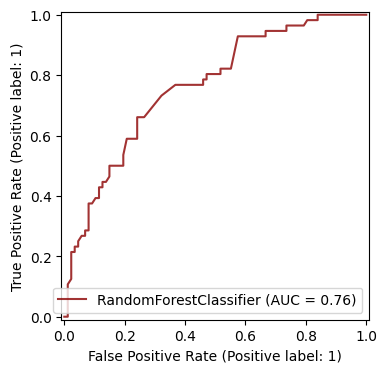

In [96]:
# Plot ROC curve and calculate AUC
plt.figure(figsize=(6,4))
ax = plt.gca()
rfc_disp = RocCurveDisplay.from_estimator(rfc, 
                                          X2_test, 
                                          y2_test, 
                                          ax=ax,
                                          alpha=0.8,
                                          c="darkred")
plt.show()

### Jupyter notebook --footer info-- (please always provide this at the end of each submitted notebook)

In [97]:
import os
import platform
import socket
from platform import python_version
from datetime import datetime

print('-----------------------------------')
print(os.name.upper())
print(platform.system(), '|', platform.release())
print('Datetime:', datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print('Python Version:', python_version())
print('-----------------------------------')

-----------------------------------
POSIX
Linux | 6.8.0-1030-azure
Datetime: 2025-11-30 14:15:31
Python Version: 3.11.13
-----------------------------------
